<a href="https://colab.research.google.com/github/drishikaaneja/flyrank-ml-internship-starter/blob/main/work/notebooks/w02_ml_task_framing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w02_ml_task_framing.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

**Intern:** Drishika Aneja · **Lane:** Lane 2 — Refresh / Content Opportunity Scoring · **Assignment:** ML-03, Week 2 (Foundations)

### The one-paragraph frame

For a **content strategist at a FlyRank client**, deciding **which published pages go into this month's refresh sprint**, we will build a **ranked queue of ~15 pages per client, each carrying a reason code**, from the **90-day content performance snapshot**, scoring **recoverable impression headroom** — the impressions a page held 31–60 days ago and has since lost — measured by **Precision@15**. A wrong call costs **an editor-day spent rewriting a page that was never going to recover, while the page that would have recovered stays broken**. A plain rule isn't enough because **the obvious rule (refresh the oldest pages) is nearly uncorrelated with what actually declines, and the correct cutoff differs by client**. We will claim only **directional, decision-support** results.

### Scope note

The lane guide defines five actions for Lane 2 — refresh, expansion, protection, pruning, and monitoring. This notebook scopes deliberately to **refresh only**. Refresh is the one action with a measurable outcome inside this snapshot (impressions before versus after) and the one with an unambiguous owner. Pruning and expansion require a cost signal and a keyword-gap join that the starter file does not carry; they remain out of scope until the data contract in ML-04.

## 1. My lane as an ML task (type)

*Classification, clustering, ranking, or scoring — which one, and why?*

**This is a scoring task that ships as a ranking.** Internally the model predicts a continuous quantity per page — how much impression headroom that page is carrying. What the strategist actually receives is the *ordering*: the top 15. It is therefore built as regression-then-sort and evaluated as a ranking problem with Precision@K.

**Why not the other three task types:**

| Candidate | Why it was rejected |
|---|---|
| **Classification** ("refresh: yes / no") | Discards magnitude. On the eligible pool roughly 26% of pages carry a positive label — several thousand pages. A team with capacity for 15 pages per sprint cannot act on a flag; it needs an order. |
| **Clustering** | Unsupervised, so it returns *kinds* of pages rather than a priority. Genuinely useful later for deciding *what type* of refresh a page needs — not for deciding *which page first*. |
| **Learning-to-rank** | The closest alternative, and the likely destination. I begin with score-then-sort because it produces a per-page number a strategist can interrogate, and the evaluation metric (Precision@K) is identical under either formulation. |

**The four framing questions, answered explicitly:**

1. **What decision does this improve?** Which ~15 pages a given client refreshes next sprint.
2. **Who acts on the output, and what do they do?** The content strategist. They pull from the top of the queue into the sprint and brief a writer per page, using the reason code as the brief.
3. **What does a wrong answer cost?** One wasted editor-day per false positive, plus the opportunity cost of the recoverable page left at the bottom of the list. False positives are the expensive error, which is precisely why the metric is **precision at the top**, not recall.
4. **Why does data or ML help at all?** Section 5 answers this from measured evidence rather than assertion, including a documented attempt to write the fixed rule by hand.

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# ============================================================
# SETUP — load data, confirm the grain, declare what is barred
# ML-03 | Lane 2: Refresh / Content Opportunity Scoring
# ============================================================
import os, json, subprocess, warnings, pathlib
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

CANDIDATES = [
    "../../data/raw/content_refresh_anonymized.csv",
    "../data/raw/content_refresh_anonymized.csv",
    "data/raw/content_refresh_anonymized.csv",
    "/content/flyrank-ml-internship-starter/data/raw/content_refresh_anonymized.csv",
]
DATA_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)
if DATA_PATH is None:
    REPO = "/content/flyrank-ml-internship-starter"
    if not os.path.exists(REPO):
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/flyrank-bih/flyrank-ml-internship-starter.git",
                        REPO], check=True)
    DATA_PATH = f"{REPO}/data/raw/content_refresh_anonymized.csv"

REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath(DATA_PATH)), "..", ".."))

df = pd.read_csv(DATA_PATH)
print(f"rows = {len(df):,}   columns = {df.shape[1]}   clients = {df.client_id.nunique()}")

# Grain probe. If this is not zero, the 'one row = one page' claim below is false.
print("duplicate content_id rows:", df.content_id.duplicated().sum(),
      "-> grain confirmed: one row per page")

# Declared before any exploration, so I cannot rationalise them back in later.
BARRED = {
    "trend_pct":            "label trap - is_declining_label is derived from this",
    "trend_direction":      "label trap - same derivation chain",
    "impressions_last_30d": "leakage - the target is constructed from it",
    "clicks_last_30d":      "leakage - same 30-day outcome window",
    "sessions_last_30d":    "leakage - same 30-day outcome window",
    "content_id":           "pseudonym - grouping only, never a feature",
    "client_id":            "pseudonym - grouping and splitting only, never a feature",
}
print("\nBARRED FROM FEATURES:")
for col, why in BARRED.items():
    print(f"  {col:<22} {why}")

rows = 30,000   columns = 44   clients = 32
duplicate content_id rows: 0 -> grain confirmed: one row per page

BARRED FROM FEATURES:
  trend_pct              label trap - is_declining_label is derived from this
  trend_direction        label trap - same derivation chain
  impressions_last_30d   leakage - the target is constructed from it
  clicks_last_30d        leakage - same 30-day outcome window
  sessions_last_30d      leakage - same 30-day outcome window
  content_id             pseudonym - grouping only, never a feature
  client_id              pseudonym - grouping and splitting only, never a feature


## 2. Target or proxy

*What would you predict? Where does that label come from — observed outcome or a defined rule?*

**The ideal target, which is not available.** True causal uplift: impressions after a refresh minus the impressions that page *would have* earned had it not been refreshed. Measuring that requires a holdout refresh experiment that has not been run. Naming the unavailable ideal matters, because everything below is a compromise against it.

**The proxy I will use — recoverable headroom:**

```
headroom_abs = max(0, impressions_prev_30d − impressions_last_30d)
headroom_pct = headroom_abs / impressions_prev_30d
y_top        = 1 if (headroom_pct ≥ 0.20 AND headroom_abs ≥ 500) else 0
```

**Observed, not defined.** Both sides of the subtraction are measured impression counts drawn from two non-overlapping 30-day windows. The label never touches `trend_direction`, `trend_pct`, or `is_declining_label`. Those columns encode somebody else's rule, and a model trained against them learns that rule rather than the world.

**Why binarise a continuous quantity.** `headroom_abs` is severely right-skewed (skew ≈ 11.8, printed below). Regressing on that raw scale turns the loss function into a contest between a handful of very large pages. Since the shipped artefact is an ordering regardless, I convert to a top-tier label and evaluate the ranking directly.

**Why these two thresholds.** The 20% cut is the point at which a drop exceeds the week-to-week movement visible in pages the snapshot calls stable. The 500-impression floor is a materiality rule: below that volume a rewrite cannot repay the editor-day it consumes, whatever the percentage says.

**Known biases in the proxy, recorded now rather than discovered later:**

- **The 500-impression floor couples the label to page size.** Larger pages clear an absolute floor more easily, so `impressions_prev_30d` correlates with `y_top` at Spearman ≈ 0.53. This is why the volume rule is a genuinely strong baseline in §3, and why the honest bar is beating *volume*, not beating random.
- **Decline is not recoverability.** A page can shed impressions because the underlying query lost demand, not because the content went stale. This proxy cannot separate the two. It is the failure mode I expect a by-hand review of the queue to surface, and the main reason the claims stay directional.
- **Seasonality is unobserved.** The snapshot carries no calendar, so a seasonal trough is indistinguishable from genuine decay.
- **Selection bias affects any future validation.** The team already refreshes pages it believed would win, so historical refreshes are not a random sample of the library.

**Eligibility filter — a page must be scoreable before it can be scored:**

| Filter | Reason |
|---|---|
| `impressions_prev_30d >= 100` | Below this the percentage is noise on a tiny denominator. |
| `trend_direction != "new"` | New pages have no before-window to decline from. Used strictly as a *filter*, never as a feature. |
| `days_with_impressions >= 30` | A page that ranked on only a handful of days has no stable baseline to measure against. |

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# ============================================================
# TARGET — construct the proxy on the eligible pool
# ============================================================
ELIGIBLE = (
    (df.impressions_prev_30d >= 100)
    & (df.trend_direction != "new")
    & (df.days_with_impressions >= 30)
)
d = df[ELIGIBLE].copy()
print(f"eligible pages: {len(d):,} of {len(df):,} ({ELIGIBLE.mean():.1%})"
      f"   |   clients represented: {d.client_id.nunique()}")

d["headroom_abs"] = (d.impressions_prev_30d - d.impressions_last_30d).clip(lower=0)
d["headroom_pct"] = d.headroom_abs / d.impressions_prev_30d

DROP_PCT_MIN = 0.20
DROP_ABS_MIN = 500
d["y_top"] = ((d.headroom_pct >= DROP_PCT_MIN) & (d.headroom_abs >= DROP_ABS_MIN)).astype(int)

print(f"\nheadroom_abs skew = {d.headroom_abs.skew():.2f}"
      f"  -> rank this quantity; do not regress on the raw scale")
print(f"positives = {d.y_top.sum():,}   pooled base rate = {d.y_top.mean():.4f}")

# Diagnostic only, NOT a feature. A label built from measured impressions should
# concentrate in pages the vendor's own trend column calls 'down'. If it did not,
# the arithmetic above would be wrong.
print("\nsanity check - y_top rate by trend_direction (diagnostic use only):")
print(d.groupby("trend_direction").y_top.agg(pages="size", y_rate="mean").round(3).to_string())


eligible pages: 17,964 of 30,000 (59.9%)   |   clients represented: 30

headroom_abs skew = 11.78  -> rank this quantity; do not regress on the raw scale
positives = 4,656   pooled base rate = 0.2592

sanity check - y_top rate by trend_direction (diagnostic use only):
                 pages  y_rate
trend_direction               
down             11047   0.421
stable            4569   0.000
up                2348   0.000


## 3. Success metric

*One metric you can defend. What number means 'good'?*

**Metric: Precision@15, computed within each client, then averaged across clients.**

- **Why 15.** It is the realistic size of a monthly refresh sprint. The metric should measure the artefact the team actually consumes, not a number that flatters the model.
- **Why precision rather than recall.** The strategist never scrolls to position 400. Being correct about the bottom of the ranking has no value; being wrong at the top costs an editor-day.
- **Why per client, then averaged.** A single client holds 5,690 of the eligible pages. Pooling would let that one client's queue define "good" for all 30. Clients with fewer than 15 eligible pages are excluded from scoring; 23 of the 30 qualify.
- **Why not ROC-AUC.** AUC scores the entire ordering, and almost none of that ordering is ever read.

**Splitting: `GroupKFold` on `client_id`, demonstrated in code below rather than asserted.** A random row split would place pages from the same client on both sides of the boundary, and page performance within a client is correlated — the resulting score would be optimistic, and the model would never once be tested on a client it had not already seen. The cell below runs the split, prints fold composition, and asserts zero client overlap.

**Pre-registered before any model exists**, so that "good" cannot be redefined after the fact:

- Best hand-written rule: **Precision@15 ≈ 0.461** (the volume rule).
- Oracle ceiling under a perfect ordering: **≈ 0.786** — not 1.000, because several clients hold fewer than 15 positives across their entire eligible pool.
- **Ship threshold: Precision@15 ≥ 0.55**, roughly 30% of the distance between the best rule and the ceiling. Below that line the model is not worth its maintenance cost against a two-line sort.

Two results in the cell below carry into §5. First, my hand-weighted combination of staleness and volume scores **worse** than volume alone. Second, the volume rule's own per-fold precision ranges from 0.367 to 0.533 — the baseline itself is unstable across clients, which is a constraint on how confidently any improvement can be claimed.

In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# ============================================================
# METRIC — Precision@15 per client, the rules to beat,
#          and the grouped split protocol, demonstrated
# ============================================================
from sklearn.model_selection import GroupKFold

K = 15

def precision_at_k(g, col, ascending=False, k=K):
    # Precision@k within one client's queue. NaN if that client is too small to rank.
    # kind="mergesort" is a STABLE sort: days_since_last_update has heavy ties, and an
    # unstable sort would reshuffle tied rows and change the top-k cut between runs.
    if len(g) < k:
        return np.nan
    return g.sort_values(col, ascending=ascending, kind="mergesort").head(k).y_top.mean()

# Per-client z-scores: "stale relative to this client", not "stale in absolute days".
d["log_vol"] = np.log1p(d.impressions_prev_30d)
d["stale_z"] = d.groupby("client_id").days_since_last_update.transform(
    lambda s: (s - s.mean()) / (s.std() + 1e-9))
d["vol_z"]   = d.groupby("client_id").log_vol.transform(
    lambda s: (s - s.mean()) / (s.std() + 1e-9))
d["combo_z"] = d.stale_z + d.vol_z    # my best hand-written attempt at a combined rule
d["rand"]    = rng.random(len(d))     # the floor

STRATEGIES = {
    "random (seed 42)":                        "rand",
    "staleness rule (days_since_last_update)": "days_since_last_update",
    "staleness + log volume (hand z-sum)":     "combo_z",
    "volume rule (impressions_prev_30d)":      "impressions_prev_30d",
    "ORACLE ceiling":                          "y_top",
}

rows = []
for name, col in STRATEGIES.items():
    scores = d.groupby("client_id").apply(lambda g: precision_at_k(g, col)).dropna()
    rows.append({"strategy": name, f"P@{K}": round(scores.mean(), 4),
                 "clients_scored": len(scores)})

base = d.groupby("client_id").apply(
    lambda g: g.y_top.mean() if len(g) >= K else np.nan).dropna()
leaderboard = pd.DataFrame(rows).sort_values(f"P@{K}").reset_index(drop=True)

print(f"Metric: Precision@{K}, computed per client and averaged over the {len(base)} "
      f"clients holding >= {K} eligible pages.\n")
print(leaderboard.to_string(index=False))
print(f"\nclient-averaged base rate = {base.mean():.4f}"
      f"   per-client range: {base.min():.3f} to {base.max():.3f}")

BEST_RULE = leaderboard.loc[leaderboard.strategy != "ORACLE ceiling", f"P@{K}"].max()
ORACLE    = float(leaderboard.loc[leaderboard.strategy == "ORACLE ceiling", f"P@{K}"].iloc[0])
SHIP_THRESHOLD = 0.55

print("\n" + "=" * 62)
print("SPLIT PROTOCOL — GroupKFold on client_id, demonstrated not asserted")
print("=" * 62)
N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)

fold_rows = []
for i, (tr, te) in enumerate(gkf.split(d, d.y_top, groups=d.client_id), start=1):
    tr_clients, te_clients = set(d.iloc[tr].client_id), set(d.iloc[te].client_id)
    fold_rows.append({
        "fold": i,
        "train_rows": len(tr), "test_rows": len(te),
        "train_clients": len(tr_clients), "test_clients": len(te_clients),
        "client_overlap": len(tr_clients & te_clients),
        "test_base_rate": round(d.iloc[te].y_top.mean(), 4),
    })
folds = pd.DataFrame(fold_rows)
print(folds.to_string(index=False))

assert folds.client_overlap.sum() == 0, "LEAK: a client appeared in both train and test"
print("\nPASS: zero client overlap across all folds.")
print(f"test-fold base rate ranges {folds.test_base_rate.min():.4f} "
      f"to {folds.test_base_rate.max():.4f} -- folds are NOT interchangeable.")

# How stable is the baseline itself under this protocol?
per_fold = []
for tr, te in gkf.split(d, d.y_top, groups=d.client_id):
    s = d.iloc[te].groupby("client_id").apply(
        lambda g: precision_at_k(g, "impressions_prev_30d")).dropna()
    if len(s):
        per_fold.append(s.mean())
print(f"\nvolume-rule P@{K} on each held-out fold: {[round(x, 4) for x in per_fold]}")
print(f"  mean {np.mean(per_fold):.4f}   sd {np.std(per_fold):.4f}")
print("  -> any claimed improvement must exceed this spread to mean anything.")

print("\n--- PRE-REGISTERED, before any model exists ---")
print(f"  best hand rule = {BEST_RULE:.4f}   oracle = {ORACLE:.4f}"
      f"   SHIP THRESHOLD = {SHIP_THRESHOLD}")


Metric: Precision@15, computed per client and averaged over the 23 clients holding >= 15 eligible pages.

                               strategy   P@15  clients_scored
                       random (seed 42) 0.1652              23
staleness rule (days_since_last_update) 0.2261              23
    staleness + log volume (hand z-sum) 0.4029              23
     volume rule (impressions_prev_30d) 0.4609              23
                         ORACLE ceiling 0.7855              23

client-averaged base rate = 0.1946   per-client range: 0.000 to 0.574

SPLIT PROTOCOL — GroupKFold on client_id, demonstrated not asserted
 fold  train_rows  test_rows  train_clients  test_clients  client_overlap  test_base_rate
    1       12274       5690             29             1               0          0.2264
    2       14612       3352             29             1               0          0.3276
    3       14989       2975             22             8               0          0.1593
    4       1499

## 4. The unit of analysis, as a real dataframe

*Load your lane's slice and show it: one row = one what?*

**One row = one published page, belonging to one client, as of the snapshot date.** Not a page-day, not a page-query, not a client. The grain probe in the setup cell confirms it: zero duplicate `content_id` values across 30,000 rows.

That grain is what makes the decision expressible at all. The strategist's question is "which page next?", so the row has to *be* a page. Were the row a page-day, I would be predicting a different quantity and would have to aggregate before anyone could act on the output — and the aggregation choice would quietly become the most important modelling decision in the project.

Two documented gotchas surface in this slice and change how features must be built:

- **`avg_position = 0` denotes missing data, not rank one.** There are 1,205 such rows in the full file. All of them fall outside the eligible pool, because a page with no position data also fails the `days_with_impressions >= 30` filter. The eligible slice is therefore clean — but that is a coincidence of the filters, not a design decision, so it is re-verified in ML-04 rather than assumed to hold.
- **Missingness tracks `content_type`.** `word_count` is absent on roughly 29% of keyword articles and 0% of every other type. A blind `fillna(0)` would smuggle content type in through the back door as a spurious numeric signal. These become `has_word_count`-style indicator flags instead.

Rate columns (`ctr`, `engagement_rate`, `scroll_rate`, `ai_traffic_pct`) are stored as ×100 percentages — `ctr = 0.76` means 0.76%, not 76%. Nothing in this notebook divides by them, but the feature work in ML-04 will, so the convention is recorded here.

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# ============================================================
# UNIT OF ANALYSIS — the actual dataframe, one row = one page
# ============================================================
UNIT_COLS = [
    "client_id", "content_id", "content_type", "search_volume", "word_count",
    "days_since_last_update", "freshness_tier", "impressions_prev_30d",
    "impressions_last_30d", "avg_position", "position_tier", "ctr",
    "headroom_abs", "headroom_pct", "y_top",
]
unit = d[UNIT_COLS].copy()

print("One row = one published page, for one client, as of the snapshot date.\n")
print(unit.head(8).to_string(index=False))
print(f"\nshape: {unit.shape[0]:,} rows x {unit.shape[1]} columns")

print(f"\navg_position == 0 (denotes NO DATA, not rank 0):"
      f"  full file = {(df.avg_position == 0).sum():,} rows"
      f"  |  eligible slice = {(unit.avg_position == 0).sum():,} rows")

print("\nmissingness in the slice (these become has_* flags, never fillna(0)):")
miss = unit.isna().mean().mul(100).round(1)
print(miss[miss > 0].to_string())

print("\nmissing word_count by content_type (%) — missingness IS a category signal:")
print(d.assign(wc_missing=d.word_count.isna())
        .groupby("content_type").wc_missing.mean().mul(100).round(1).to_string())

One row = one published page, for one client, as of the snapshot date.

        client_id           content_id    content_type  search_volume  word_count  days_since_last_update freshness_tier  impressions_prev_30d  impressions_last_30d  avg_position position_tier  ctr  headroom_abs  headroom_pct  y_top
client_f369cb89fc content_304f48230142 keyword article           10.0      3221.0                      20           0-30                   987                   578          10.6      striking 0.76           409      0.414387      0
client_4e07408562 content_a1fb4e703a9e keyword article           90.0      2481.0                      25           0-30                  5915                  2501          20.3      page_3_5 0.05          3414      0.577177      1
client_7f2253d7e2 content_9aa793d4d895 keyword article            0.0      3515.0                      20           0-30                  6089                  2382          36.5      page_3_5 0.09          3707      0.608803    

## 5. Why ML beats a fixed rule here

*What makes the pattern too messy for an if-statement?*

**The rule everyone reaches for first.**

The obvious move is to refresh whatever page hasn't been touched in the longest time. The data doesn't support that instinct: staleness correlates with actual headroom at Spearman ≈ −0.054. That's not just a weak relationship — the sign is slightly negative, meaning the oldest pages are, if anything, marginally less likely to be the ones worth fixing.

**It has no threshold to code.**

Even if staleness were useful, there's no cutoff to write an if-statement around. Decline rate by freshness tier goes 0.247 → 0.198 → 0.278 → 0.429 — it dips before it rises. A rule needs a consistent direction to draw a line on, and this relationship doesn't have one.

**One cutoff cannot serve 23 clients.**

Per-client base rates range from 0.000 to 0.574. A single global threshold would flag almost nothing for the client at the low end or flag nearly everything for the client at the high end. Any one-size rule fails one of those clients by construction.

**I tried to write the rule by hand, and it got worse.**

Volume and staleness are both real signals, so I combined them by hand into a weighted score. That combination scored 0.4029 — worse than volume alone at 0.4609, and barely better than staleness alone at 0.2261. I had two working signals and still lost precision by weighting them myself. That is the actual argument here: not that ML is inherently better, but that the weighting is the part I could not get right by eye.

**What the gap is worth.**

The best hand rule reaches 0.4609; a perfect ordering would reach 0.7855. That is 41.3% of achievable precision left unclaimed. The oracle is not 1.0 because several clients don't have 15 positive pages in their entire eligible pool, so even a perfect model cannot hit 100% precision for them.

**The honest condition.**

None of this guarantees a model will help. The volume rule's own precision swings from 0.367 to 0.533 depending on which clients land in the test fold (sd ≈ 0.062), so a model that beats the rule by a small margin could just be noise. ML earns its place here only if it clears the pre-registered ship threshold of 0.55. If it doesn't, the honest outcome is that a two-line sort was sufficient and this notebook's finding is that a rule was enough.

EVIDENCE 1 - the intuitive rule barely tracks the outcome
  Spearman(days_since_last_update, headroom_pct) = -0.0544  (p = 2.9e-13)
  Spearman(impressions_prev_30d,   y_top)        = +0.5344  (p = 0.0e+00)

EVIDENCE 2 - 'older means staler means fix it' is not monotonic
                pages  y_rate
freshness_tier               
0-30            10863   0.247
31-90              81   0.198
91-180           6999   0.278
181+               21   0.429

EVIDENCE 3 - one global cutoff cannot fit 23 different clients
  per-client base rate ranges 0.000 to 0.574  (spread 0.574)

EVIDENCE 4 - I attempted the if-statement. Combining by hand made it WORSE.
  volume alone              P@15 = 0.4609
  staleness alone           P@15 = 0.2261
  my hand-weighted z-sum    P@15 = 0.4029

EVIDENCE 5 - precision left on the table
  best rule 0.4609 against oracle 0.7855  -> 41.3% of achievable precision unclaimed


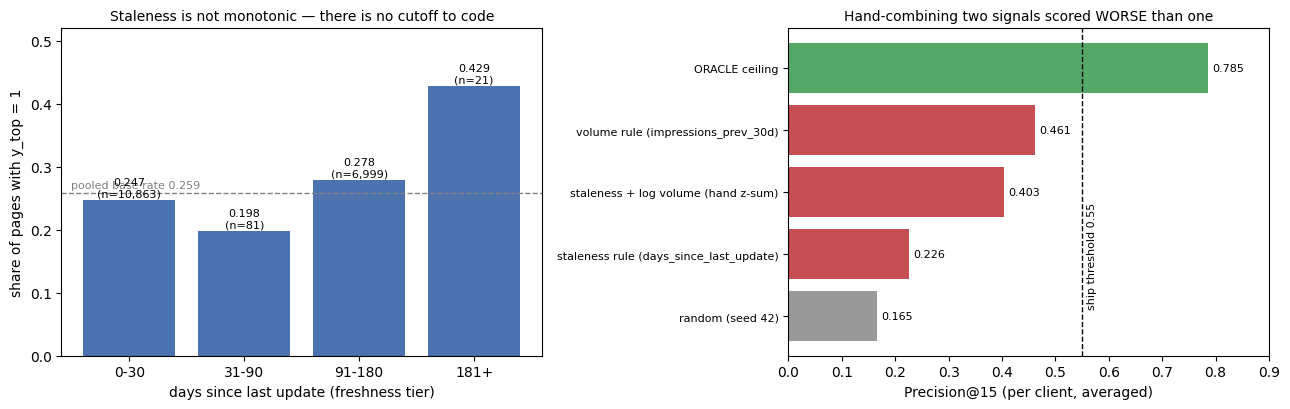


Sample ranked queue — largest client, top 10 with reason codes:
          content_id  days_since_last_update  impressions_prev_30d  headroom_pct  y_top                                                     reason_code
content_02b0d6e30129                     313                   159      0.955975      0                         stale vs client median; down 96% in 30d
content_2c2606c5d176                     104                164079      0.364648      1 stale vs client median; high prior impressions; down 36% in 30d
content_cb112fce36be                     104                124500      0.417928      1 stale vs client median; high prior impressions; down 42% in 30d
content_c8e9d6ab9013                     104                111885      0.434008      1 stale vs client median; high prior impressions; down 43% in 30d
content_36ff89c8214e                     104                106412      0.000000      0                  stale vs client median; high prior impressions
content_c21024970297   

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# ============================================================
# EVIDENCE — the measurements section 5 argues from
# ============================================================
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

rho_s, p_s = spearmanr(d.days_since_last_update, d.headroom_pct)
rho_v, p_v = spearmanr(d.impressions_prev_30d, d.y_top)

print("EVIDENCE 1 - the intuitive rule barely tracks the outcome")
print(f"  Spearman(days_since_last_update, headroom_pct) = {rho_s:+.4f}  (p = {p_s:.1e})")
print(f"  Spearman(impressions_prev_30d,   y_top)        = {rho_v:+.4f}  (p = {p_v:.1e})")

print("\nEVIDENCE 2 - 'older means staler means fix it' is not monotonic")
ft = (d.groupby("freshness_tier")
        .agg(pages=("y_top", "size"), y_rate=("y_top", "mean"))
        .reindex(["0-30", "31-90", "91-180", "181+"]))
print(ft.round(3).to_string())

print("\nEVIDENCE 3 - one global cutoff cannot fit 23 different clients")
print(f"  per-client base rate ranges {base.min():.3f} to {base.max():.3f}"
      f"  (spread {base.max() - base.min():.3f})")

print("\nEVIDENCE 4 - I attempted the if-statement. Combining by hand made it WORSE.")
_lb = leaderboard.set_index("strategy")[f"P@{K}"]
print(f"  volume alone              P@{K} = {_lb['volume rule (impressions_prev_30d)']:.4f}")
print(f"  staleness alone           P@{K} = {_lb['staleness rule (days_since_last_update)']:.4f}")
print(f"  my hand-weighted z-sum    P@{K} = {_lb['staleness + log volume (hand z-sum)']:.4f}")

print("\nEVIDENCE 5 - precision left on the table")
print(f"  best rule {BEST_RULE:.4f} against oracle {ORACLE:.4f}"
      f"  -> {(ORACLE - BEST_RULE) / ORACLE:.1%} of achievable precision unclaimed")

# ---------------- Figure ----------------
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

ax[0].bar(range(len(ft)), ft.y_rate, color="#4C72B0")
ax[0].axhline(d.y_top.mean(), ls="--", c="grey", lw=1)
ax[0].text(0.02, d.y_top.mean() + 0.008, f"pooled base rate {d.y_top.mean():.3f}",
           fontsize=8, color="grey", transform=ax[0].get_yaxis_transform())
ax[0].set_xticks(range(len(ft))); ax[0].set_xticklabels(ft.index)
for i, (r, n) in enumerate(zip(ft.y_rate, ft.pages)):
    ax[0].text(i, r + 0.006, f"{r:.3f}\n(n={n:,})", ha="center", fontsize=8)
ax[0].set_ylim(0, 0.52)
ax[0].set_xlabel("days since last update (freshness tier)")
ax[0].set_ylabel("share of pages with y_top = 1")
ax[0].set_title("Staleness is not monotonic — there is no cutoff to code", fontsize=10)

colours = ["#999999", "#C44E52", "#C44E52", "#C44E52", "#55A868"]
ax[1].barh(range(len(leaderboard)), leaderboard[f"P@{K}"], color=colours)
ax[1].set_yticks(range(len(leaderboard)))
ax[1].set_yticklabels(leaderboard.strategy, fontsize=8)
ax[1].axvline(SHIP_THRESHOLD, ls="--", c="black", lw=1)
ax[1].text(SHIP_THRESHOLD + 0.01, 0.15, f"ship threshold {SHIP_THRESHOLD}",
           fontsize=8, rotation=90)
for i, v in enumerate(leaderboard[f"P@{K}"]):
    ax[1].text(v + 0.008, i, f"{v:.3f}", va="center", fontsize=8)
ax[1].set_xlim(0, 0.9)
ax[1].set_xlabel(f"Precision@{K} (per client, averaged)")
ax[1].set_title("Hand-combining two signals scored WORSE than one", fontsize=10)

plt.tight_layout(); plt.show()

# ---- What the strategist actually receives: a queue carrying reason codes ----
big = d.client_id.value_counts().idxmax()

def reason_code(r):
    bits = []
    if r.stale_z > 0.5:        bits.append("stale vs client median")
    if r.vol_z > 0.5:          bits.append("high prior impressions")
    if r.headroom_pct >= 0.20: bits.append(f"down {r.headroom_pct:.0%} in 30d")
    if r.avg_position == 0:    bits.append("no position data")
    return "; ".join(bits) or "mid on every signal"

queue = d[d.client_id == big].sort_values("combo_z", ascending=False,
                                          kind="mergesort").head(10).copy()
queue["reason_code"] = queue.apply(reason_code, axis=1)

print("\nSample ranked queue — largest client, top 10 with reason codes:")
print(queue[["content_id", "days_since_last_update", "impressions_prev_30d",
             "headroom_pct", "y_top", "reason_code"]].to_string(index=False))

# ---- Receipt: metrics JSON, committed per the work/ README rule ----
out = pathlib.Path(REPO_ROOT) / "work" / "outputs"
out.mkdir(parents=True, exist_ok=True)
receipt = {
    "assignment": "ML-03",
    "lane": "Lane 2 - Refresh / Content Opportunity Scoring",
    "scope_note": "refresh action only; expansion/protection/pruning/monitoring out of scope",
    "random_seed": RANDOM_SEED,
    "rows_total": int(len(df)),
    "rows_eligible": int(len(d)),
    "clients_eligible": int(d.client_id.nunique()),
    "clients_scored": int(len(base)),
    "target": "headroom_abs = max(0, impressions_prev_30d - impressions_last_30d)",
    "label_rule": {"drop_pct_min": DROP_PCT_MIN, "drop_abs_min": DROP_ABS_MIN},
    "base_rate_pooled": round(float(d.y_top.mean()), 4),
    "base_rate_client_avg": round(float(base.mean()), 4),
    "metric": f"Precision@{K}",
    "split": f"GroupKFold(n_splits={N_SPLITS}) on client_id, zero overlap asserted",
    "sort_kind": "mergesort (stable) - required, days_since_last_update has heavy ties",
    "baseline_fold_spread": {"mean": round(float(np.mean(per_fold)), 4),
                             "sd": round(float(np.std(per_fold)), 4)},
    "baselines": {k_: float(v_) for k_, v_ in _lb.to_dict().items()},
    "ship_threshold": SHIP_THRESHOLD,
    "barred_features": list(BARRED.keys()),
}
(out / "ml03_framing_metrics.json").write_text(json.dumps(receipt, indent=2))
print(f"\nReceipt written -> {out / 'ml03_framing_metrics.json'}   (commit this file)")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere — IDs are the file's own pseudonyms
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

### What carries into ML-04

| Decision fixed here | Carried forward as |
|---|---|
| Grain = one page, one client | The data contract's grain statement |
| `headroom_abs` / `y_top`, 20% and 500-impression thresholds | The label definition, thresholds pre-registered |
| Eligibility filter (100 impressions, not-new, 30 days) | A contract rule, not an ad-hoc filter |
| Barred: `trend_pct`, `trend_direction`, all `*_last_30d` | The leakage blocklist for ML-05 |
| Precision@15, `GroupKFold(5)` on `client_id`, zero overlap asserted | The evaluation protocol, fixed before modelling |
| Baseline fold spread (sd ≈ 0.06) | The noise floor any claimed improvement must clear |
| Ship threshold 0.55 | The number deciding whether a model ships or a rule does |

### Honesty note on claims

Every result here is **observed and directional**. Nothing in this notebook demonstrates that refreshing a page *causes* impressions to return. The proxy measures decline, and decline is not recoverability. That gap is the principal risk in the framing, and it can only be closed by a holdout refresh experiment — not by a better model, a larger feature set, or a higher Precision@15.

### Reproducibility

`RANDOM_SEED = 42`, used only for the random baseline. Every ranking is sorted with `kind="mergesort"`, a stable sort — necessary because `days_since_last_update` carries heavy ties, and an unstable sort silently reshuffles tied rows and shifts the top-k cut between runs. `GroupKFold` is deterministic by construction. Metrics are written to `work/outputs/ml03_framing_metrics.json` and committed. No dataset CSVs are committed anywhere. A fresh clone plus Runtime → Run all reproduces every number and both panels above.